In [2]:
import pandas as pd
import numpy as np
import sklearn as sk

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_sample_weight

In [3]:
df_red = pd.read_csv('winequality-red.csv', delimiter=';')

df_red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df_red.info()

print("Nulls - ", df_red.isnull().sum())

print("Stats - ", df_red.describe())

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
Nulls -  fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               

In [5]:
df_red['acidity_sum'] = df_red['fixed acidity'] + df_red['volatile acidity']
df_red['alcoh_acidity_ratio'] = df_red['alcohol'] / df_red['volatile acidity']

print(df_red.corr()['quality'].sort_values())

volatile acidity       -0.390558
total sulfur dioxide   -0.185100
density                -0.174919
chlorides              -0.128907
pH                     -0.057731
free sulfur dioxide    -0.050656
residual sugar          0.013732
acidity_sum             0.085709
fixed acidity           0.124052
citric acid             0.226373
sulphates               0.251397
alcoh_acidity_ratio     0.440859
alcohol                 0.476166
quality                 1.000000
Name: quality, dtype: float64


In [11]:
x = df_red.drop('quality', axis=1)
y = df_red['quality']

x_train, x_test, y_train, y_test = sk.model_selection.train_test_split(x, y, test_size=0.2, random_state=42)

sc = sk.preprocessing.StandardScaler()

x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

# weights = compute_sample_weight(class_weight='balanced', y=y_train)

model = sk.linear_model.RidgeCV(alphas=[0.5, 1.0, 10, 50], cv=5)
# model.fit(x_train_scaled, y_train, sample_weight=weights) (weighting is not working (number become negative))
model.fit(x_train_scaled, y_train)


score = model.score(x_test_scaled, y_test)
print('Best alpha - ',model.alpha_)
print('Determination - ',score)

Best alpha -  50.0
Determination -  0.4013866778604539


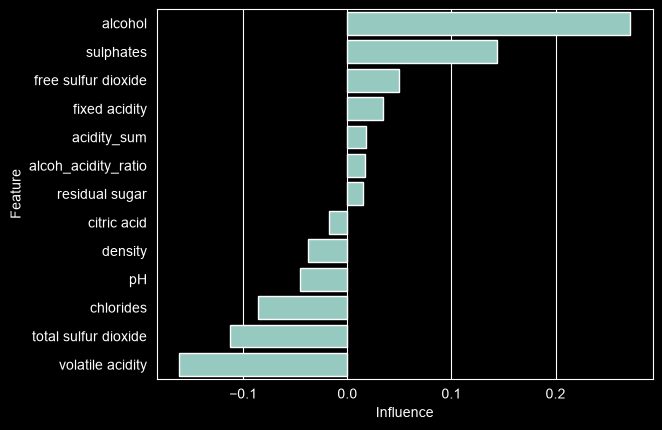

In [7]:
feature_influence = pd.DataFrame(
    {'Feature':x.columns, 'Influence':model.coef_}
).sort_values(by='Influence', ascending=False)

sns.barplot(data = feature_influence, x='Influence', y='Feature')
plt.show()

# This image shows that the most influence on the predict result has alcohol feature

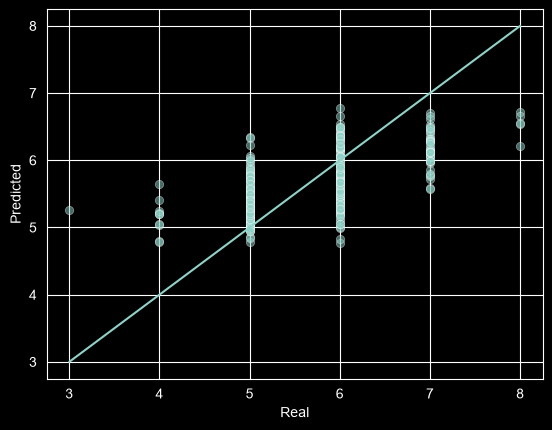

In [8]:
y_predicted = model.predict(x_test_scaled)

result = pd.DataFrame({'Real':y_test, 'Predicted': y_predicted})

sns.scatterplot(data=result, x='Real', y='Predicted', alpha=0.5)
sns.lineplot(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()])
plt.show()

# This image shows that model predicted numbers 5 and 6 the most frequently